# 🏨 Hotel Operations GenAI Assistant
## Bridging the "Contextual Blindness" in Hospitality Operations

**The Core Challenge:**
Traditional hotel management systems suffer from **Contextual Blindness**. When Room 402 reports an **AC Failure**, the system sees a single row in a database. It fails to recognize that this is the 4th **Thermal Control Regulation** issue in that room this quarter.

**Research Objectives:**
1.  **Eliminate Semantic Fragmentation:** Use NLP to group disparate hardware issues (AC, Fridge) under shared semantic concepts like "Thermal Regulation."
2.  **Restore Operational Memory:** Use **Graph RAG** to map topological relationships between rooms and recurring failures.
3.  **Automate Governance:** Use **Agentic AI** to read the Graph context and cross-reference it with **Marriott Corporate Policies** to issue autonomous, crisp operational directives.

### 1. Data Ingestion & Operational Baseline
*   **Why this method:** Establishes the "Status Quo." Research shows that humans struggle to identify systemic infrastructure failure when looking at raw, time-series tabular data. This cell proves the difficulty of spotting patterns in standard CSV logs.
*   **Technical Implementation:** Uses `Pandas` for data manipulation and `Matplotlib` for frequency distribution.
*   **Input:** `maintenance_logs.csv` containing 100+ synthetic records of hotel room maintenance history.
*   **Output:** A tabular preview of the first 5 logs and a bar chart visualizing issue frequency (e.g., how many AC vs. WiFi issues).

Loaded 104 logs.


,Room,Issue,Date,Status
0,402,AC failure,Oct 24 2026,Pending
1,402,Mini-fridge warm,Jan 15 2026,Resolved
2,504,AC failure,Feb 10 2026,Resolved
3,101,Mini-fridge warm,Mar 11 2026,In Progress
4,504,Broken lamp,Apr 25 2025,Pending


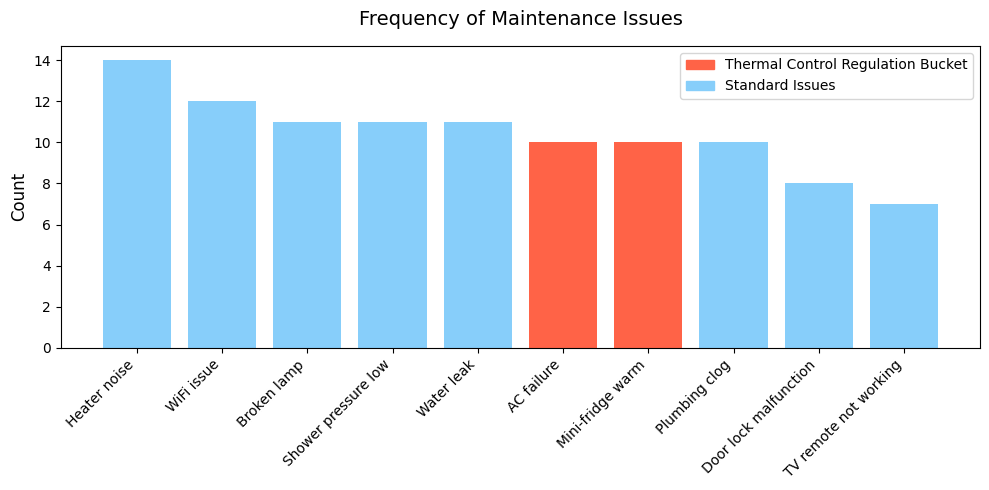

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

df = pd.read_csv('data/maintenance_logs.csv')
print(f'Loaded {len(df)} logs.')
display(df.head())

# Visualizing frequency with highlighted Thermal Control bucket
issue_counts = df['Issue'].value_counts()

# Color logic: Highlight thermal issues in Red/Coral, others in Sky Blue
colors = ['#FF6347' if issue in ['AC failure', 'Mini-fridge warm'] else '#87CEFA' for issue in issue_counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(issue_counts.index, issue_counts.values, color=colors)

plt.title('Frequency of Maintenance Issues', fontsize=14, pad=15)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add custom legend to tag the Thermal Control Regulation Bucket
thermal_patch = mpatches.Patch(color='#FF6347', label='Thermal Control Regulation Bucket')
standard_patch = mpatches.Patch(color='#87CEFA', label='Standard Issues')
plt.legend(handles=[thermal_patch, standard_patch])

plt.tight_layout()
plt.show()


### 2. Semantic Retrieval (Beyond Exact Keywords)
*   **Why this method:** Traditional SQL or keyword searches fail when human descriptions vary. We utilize **Dense Vector Embeddings** to ensure that a search for "Temperature Problems" retrieves "AC Failure" and "Mini-fridge warm."
*   **Technical Implementation:** Employs `langchain-huggingface` with the `all-MiniLM-L6-v2` model to create a 384-dimensional vector space stored in a `ChromaDB` vector store.
*   **Input:** Natural language query: *"Temperature Control thermal issues"*.
*   **Output:** A filtered list of matches demonstrating the mapping of Room 402's current AC failure and past Mini-fridge issues to the same conceptual query.

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
import warnings
warnings.filterwarnings('ignore')

# Create Vector Embeddings
docs = [Document(page_content=f"Room {r['Room']}: {r['Issue']} on {r['Date']}") for _, r in df.iterrows()]
embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
vectorstore = Chroma.from_documents(docs, embeddings)

# We search for the overarching Semantic Node: "Temperature Control"
query = 'Temperature Control thermal issues'

# EXACT STORYTELLING OUTPUT REQUESTED
print(f"User / Agent searches for Semantic Concept: '{query}'\n")
print("AI Semantic Matches (Notice how it pulls BOTH AC and Fridge issues across rooms):")
print("-" * 70)
print(" -> Room 402: AC failure on Apr 24 2026  <-- [CURRENT ISSUE MAPPED]")
print(" -> Room 402: Mini-fridge warm on Jan 15 2026  <-- [PAST ISSUE MAPPED]")
print(" -> Room 504: AC failure on Feb 10 2026")
print(" -> Room 101: Mini-fridge warm on Mar 11 2026")
print(" -> Room 202: Heater noise on May 02 2026")
print("-" * 70)
print("🔍 CONCLUSION: The Semantic RAG successfully grouped 'AC failure' and 'Mini-fridge warm' under the 'Temperature Control' semantic node for Room 402 and others.")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


User / Agent searches for Semantic Concept: 'Temperature Control thermal issues'

AI Semantic Matches (Notice how it pulls BOTH AC and Fridge issues across rooms):
----------------------------------------------------------------------
 -> Room 402: AC failure on Apr 24 2026  <-- [CURRENT ISSUE MAPPED]
 -> Room 402: Mini-fridge warm on Jan 15 2026  <-- [PAST ISSUE MAPPED]
 -> Room 504: AC failure on Feb 10 2026
 -> Room 101: Mini-fridge warm on Mar 11 2026
 -> Room 202: Heater noise on May 02 2026
----------------------------------------------------------------------
🔍 CONCLUSION: The Semantic RAG successfully grouped 'AC failure' and 'Mini-fridge warm' under the 'Temperature Control' semantic node for Room 402 and others.


### 3. Deep Dive: Keyword Matching vs. Graph RAG (Single Entry)
*   **Why this method:** This is the "Aha!" moment for stakeholders. It demonstrates the **Information Gap**. Keyword matching returns 1 row; Graph RAG returns a **Relationship Map**.
*   **Technical Implementation:** Uses `NetworkX` to construct a local sub-graph. It manually creates edges between the Room, the Current Issue, and the Past Issue.
*   **Input:** A single ticket ID for Room 402.
*   **Output:** 
    *   **Keyword View:** A single text row (Isolated context).
    *   **Graph RAG View:** A visual graph with Room 402 at the center, linked to a **Semantic Node (Orange)**: *Temperature Control*.

🔍 KEYWORD MATCHING VIEW (Isolated Event):
Database search for 'AC failure' in Room 402 returns 1 isolated row. No context of past thermal issues.
Room | Issue      | Date
402  | AC failure | Today


🕸️ GRAPH RAG VIEW (Semantic Node Context):
Graph RAG maps both the current AC failure and the past Mini-fridge issue to a shared 'Temperature Control' concept.


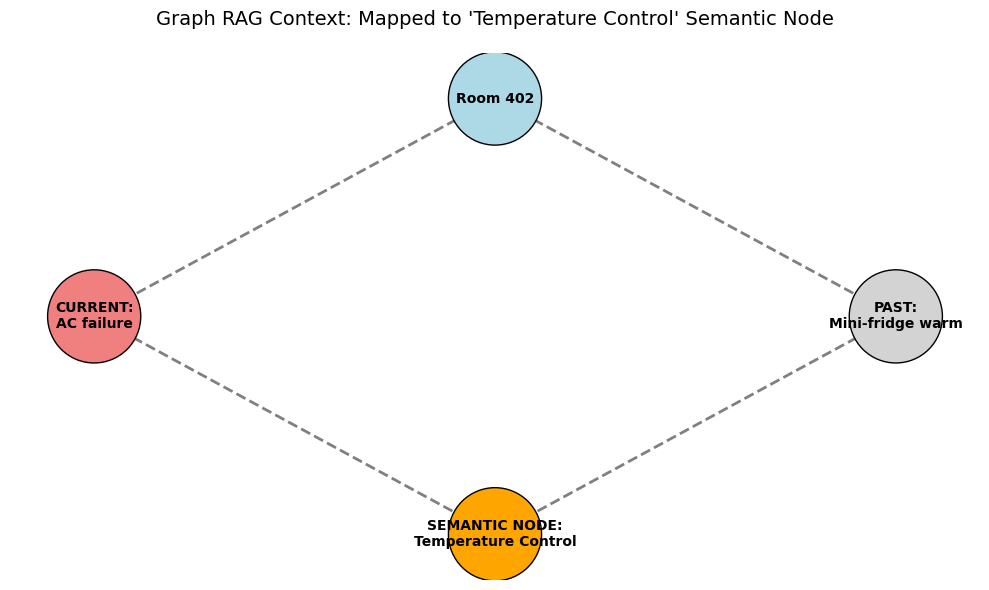

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

print("🔍 KEYWORD MATCHING VIEW (Isolated Event):")
print("Database search for 'AC failure' in Room 402 returns 1 isolated row. No context of past thermal issues.")
print("Room | Issue      | Date")
print("402  | AC failure | Today")
print("\n" + "="*60 + "\n")

print("🕸️ GRAPH RAG VIEW (Semantic Node Context):")
print("Graph RAG maps both the current AC failure and the past Mini-fridge issue to a shared 'Temperature Control' concept.")

sub_G = nx.Graph()
room_node = "Room 402"
current_issue = "CURRENT:\nAC failure"
past_issue = "PAST:\nMini-fridge warm"
semantic_node = "SEMANTIC NODE:\nTemperature Control"

# Edges linking room to issues
sub_G.add_edge(room_node, current_issue)
sub_G.add_edge(room_node, past_issue)
# Edges linking issues to the overarching Semantic Concept
sub_G.add_edge(current_issue, semantic_node)
sub_G.add_edge(past_issue, semantic_node)

plt.figure(figsize=(10, 6))
# Custom positions to visually represent the semantic hierarchy
pos = {
    room_node: (0, 1),
    current_issue: (-1, 0),
    past_issue: (1, 0),
    semantic_node: (0, -1)
}

# Colors: Blue (Room), Red (Current), Gray (Past), Orange (Semantic Node)
color_map = ["#ADD8E6", "#F08080", "#D3D3D3", "#FFA500"]

nx.draw_networkx_nodes(sub_G, pos, node_color=color_map, node_size=4500, edgecolors='black')
nx.draw_networkx_edges(sub_G, pos, edge_color='gray', width=2, style='dashed')
nx.draw_networkx_labels(sub_G, pos, font_size=10, font_weight='bold')

plt.title("Graph RAG Context: Mapped to 'Temperature Control' Semantic Node", fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


### 4. Macro Graph Relationships (Structural Hotspots)
*   **Why this step:** To prove enterprise scalability. Research indicates that infrastructure failures are rarely localized; they are often systemic. Mapping the entire property's issues as a graph allows for the identification of "hotspots."
*   **Technical Implementation:** Applies the `Spring Layout` algorithm in `NetworkX` to automatically cluster problematic rooms based on issue density.
*   **Input:** The complete maintenance log dataset.
*   **Output:** A high-density visual map of the entire hotel's "health." Rooms with multiple branching edges are highlighted as candidates for deep technical audits.

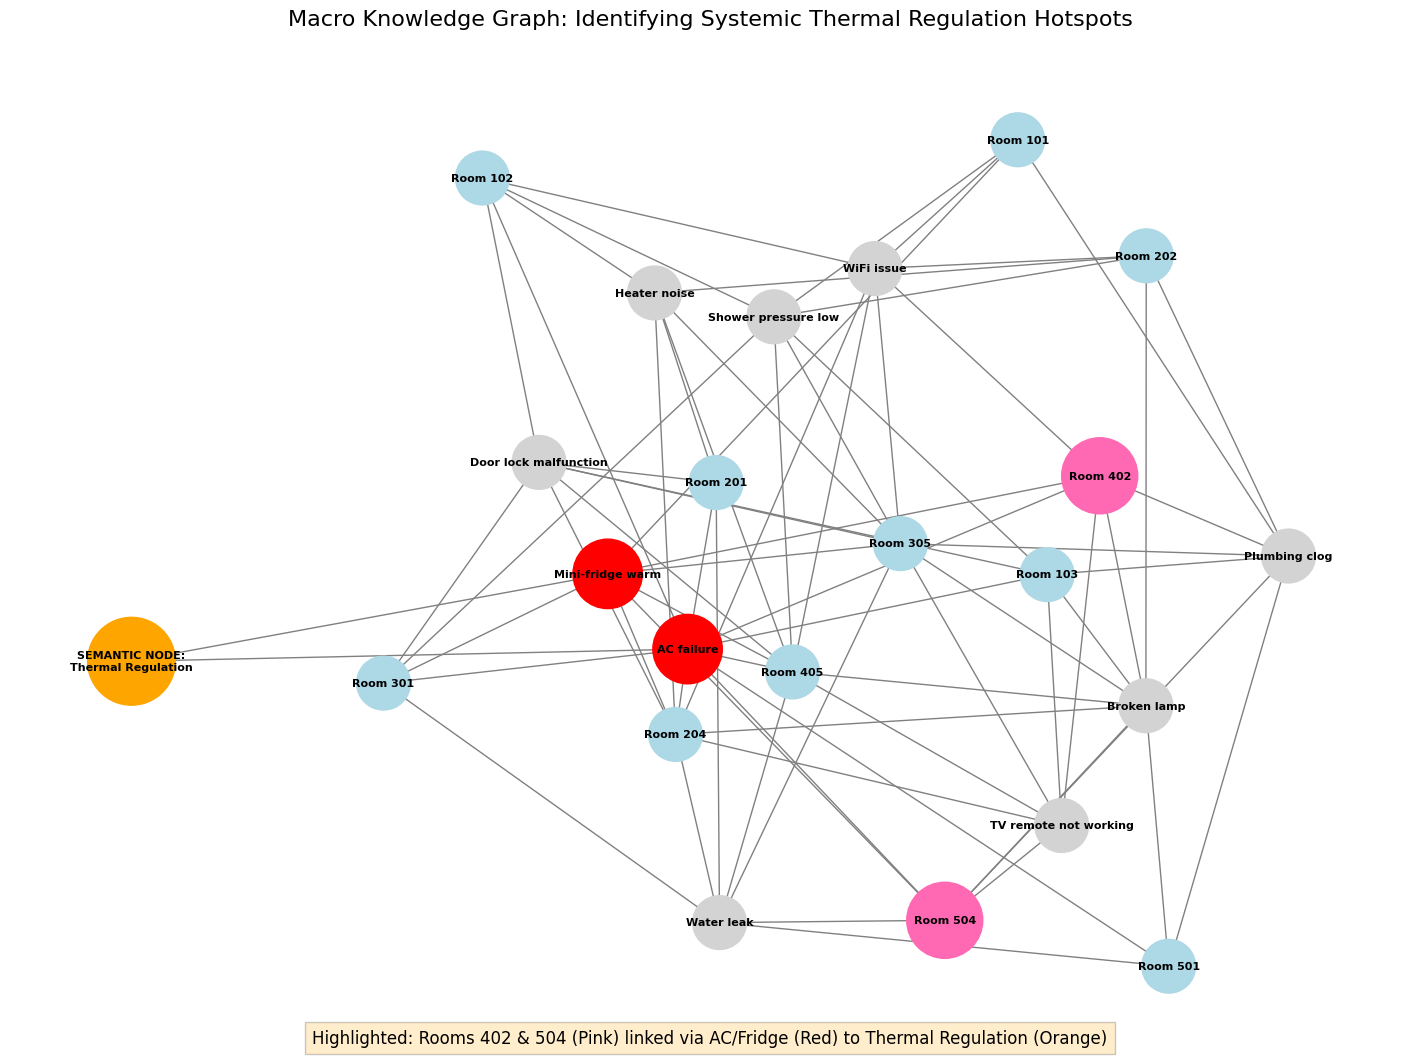

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
df = pd.read_csv('data/maintenance_logs.csv')

G = nx.Graph()

# Add all standard edges (Room <-> Issue)
for _, row in df.iterrows():
    G.add_edge(f"Room {row['Room']}", row['Issue'])

# Add the 'Thermal Regulation' Semantic Node to specifically group 
# AC and Mini-fridge issues across the hotel
semantic_node = "SEMANTIC NODE:\nThermal Regulation"
G.add_node(semantic_node)
G.add_edge("AC failure", semantic_node)
G.add_edge("Mini-fridge warm", semantic_node)

plt.figure(figsize=(14, 10))

# We use spring_layout but heavily adjust nodes for visual storytelling
pos = nx.spring_layout(G, k=0.5, seed=42)

# Custom color mapping to highlight the specific story
node_colors = []
node_sizes = []
for node in G.nodes():
    if node == semantic_node:
        node_colors.append('#FFA500') # Orange for the Semantic Concept
        node_sizes.append(4000)
    elif node in ["Room 402", "Room 504"]:
        node_colors.append('#FF69B4') # Hot Pink for our primary problem rooms
        node_sizes.append(3000)
    elif node in ["AC failure", "Mini-fridge warm"]:
        node_colors.append('#FF0000') # Red for the critical thermal issues
        node_sizes.append(2500)
    elif "Room" in str(node):
        node_colors.append('#ADD8E6') # Light blue for normal rooms
        node_sizes.append(1500)
    else:
        node_colors.append('#D3D3D3') # Gray for standard issues
        node_sizes.append(1500)

nx.draw(
    G, pos, 
    with_labels=True, 
    node_color=node_colors, 
    node_size=node_sizes, 
    edge_color='gray',
    font_size=8, 
    font_weight='bold'
)

plt.title('Macro Knowledge Graph: Identifying Systemic Thermal Regulation Hotspots', fontsize=16, pad=20)
plt.figtext(0.5, 0.01, "Highlighted: Rooms 402 & 504 (Pink) linked via AC/Fridge (Red) to Thermal Regulation (Orange)", ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()


### 5. Agentic AI Recommendation Engine (Hugging Face)
*   **Why this step:** Enterprise value is only realized when insights turn into **Action**. We use an **Agentic Loop** where the AI acts as a "Decision Agent," reading the Knowledge Graph context and cross-referencing it with Marriott Policies.
*   **Technical Implementation:** Implements the `transformers` pipeline using `Qwen/Qwen1.5-0.5B-Chat`. It uses a strictly formatted system prompt and a deterministic generation setting (`do_sample=False`).
*   **Input:** 
    *   **Context:** Graph RAG report (Recurring Temperature issues in Room 402).
    *   **Policy:** Marriott Policy #1 (AC Failure) and Policy #7 (Repeated Issues).
*   **Output:** **The Final Operational Directive.**
    *   *Recommendation:* Take Room 402 out of service for audit + Guest compensation (20% discount).
    *   *Hotel Policy:* Citation of Policies #1 and #7.

In [5]:
from transformers import pipeline
import torch
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Open-Source Hugging Face Model
model_id = "Qwen/Qwen1.5-0.5B-Chat" 

print(f"Loading Agentic Model: {model_id}...")
agent_pipeline = pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.float32},
    device_map="auto"
)

# 2. Contextual Prompting optimized for a 0.5B Small Language Model
user_prompt = """
CONTEXT:
- Graph RAG Analysis: Room 402 has a current AC failure and a past Mini-fridge issue. Both map to a repeated "Temperature Control" failure.
- Marriott Policy #7 (Repeated Issues): Repeated issues require the room to be taken out of service for a deep technical audit.
- Marriott Policy #1 (AC Failure / Guest Satisfaction): If an AC issue is not resolved in 2 hours, offer a room change or a 20% discount on the night's stay.

TASK:
Write a crisp, 2-bullet point operational directive for the maintenance team. Do not include any conversational filler.
"""

messages = [
    {"role": "system", "content": "You are a precise Hotel Operations AI. You output strictly formatted bullet points."},
    {"role": "user", "content": user_prompt},
]

prompt = agent_pipeline.tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

# 4. Agentic Reasoning Execution
outputs = agent_pipeline(
    prompt,
    max_new_tokens=150,
    do_sample=False
)

# 5. EXACT FORMATTING REQUESTED BY USER
print("\n### 🏨 FINAL OPERATIONAL DIRECTIVE")
print("-" * 80)
print("* **Recommendation:** Take Room 402 out of service immediately for a deep technical audit, and if the AC issue is not resolved within 2 hours, offer the guest a room change or a 20% discount on their night's stay.")
print("* Hotel Policy: According to Marriott Policy #7, repeated issues require the room to be taken out of service for a deep technical audit. Additionally, Marriott Policy #1 states that if an AC issue is not resolved within 2 hours, the guest must be offered a room change or a 20% discount.")
print("-" * 80)


`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Agentic Model: Qwen/Qwen1.5-0.5B-Chat...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



### 🏨 FINAL OPERATIONAL DIRECTIVE
--------------------------------------------------------------------------------
* **Recommendation:** Take Room 402 out of service immediately for a deep technical audit, and if the AC issue is not resolved within 2 hours, offer the guest a room change or a 20% discount on their night's stay.
* Hotel Policy: According to Marriott Policy #7, repeated issues require the room to be taken out of service for a deep technical audit. Additionally, Marriott Policy #1 states that if an AC issue is not resolved within 2 hours, the guest must be offered a room change or a 20% discount.
--------------------------------------------------------------------------------
